In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [7]:
df=pd.read_csv('placement.csv')
df

,branch,college_tier,cgpa,backlogs,coding_skills,dsa_score,aptitude_score,communication_skills,ml_knowledge,system_design,internships,projects_count,certifications,hackathons,open_source_contributions,extracurriculars,placement_status,salary_package_lpa
0,ECE,Tier-3,6.70,0,7.6,4.4,49.5,3.7,6.4,0.3,1,4,4,3,2,1,1,14.75
1,Chemical,Tier-2,5.70,0,5.4,7.9,72.0,8.3,6.3,1.9,0,4,0,0,0,0,0,NaN
2,EE,Tier-2,7.19,0,5.6,6.8,79.1,7.4,4.4,5.2,1,3,2,1,2,0,1,19.06
3,CE,Tier-2,6.48,0,5.2,3.1,48.4,5.0,1.1,6.7,1,4,3,0,0,0,0,NaN
4,CSE,Tier-2,6.71,1,5.9,4.7,61.2,4.3,2.7,2.8,1,2,0,3,0,1,1,13.42
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,IT,Tier-3,6.08,0,3.1,5.4,67.4,4.3,9.1,3.8,2,3,2,0,0,3,0,NaN
99996,IT,Tier-3,7.46,0,4.8,6.8,59.5,7.6,5.6,2.4,1,2,3,0,1,0,1,16.58
99997,EE,Tier-2,7.94,0,4.9,9.1,55.1,6.1,3.5,5.2,0,2,1,0,1,2,1,17.24
99998,ME,Tier-3,6.63,0,5.0,8.0,65.0,5.7,6.2,0.2,1,4,2,0,0,1,1,17.01


In [ ]:
df.isnull().sum()

branch                           0
college_tier                     0
cgpa                             0
backlogs                         0
coding_skills                    0
dsa_score                        0
aptitude_score                   0
communication_skills             0
ml_knowledge                     0
system_design                    0
internships                      0
projects_count                   0
certifications                   0
hackathons                       0
open_source_contributions        0
extracurriculars                 0
placement_status                 0
salary_package_lpa           31525
dtype: int64

In [5]:
df = df.dropna()

In [20]:
##drop all the columns except coding_skills and salary_package_lpa
df = df[['coding_skills', 'salary_package_lpa']]

#remove few rows i need only 1000 rows
df = df.head(1000)




In [21]:
df

,coding_skills,salary_package_lpa
0,7.6,14.75
2,5.6,19.06
4,5.9,13.42
5,6.7,16.47
6,7.0,16.51
...,...,...
1444,5.4,21.18
1445,4.4,19.40
1446,3.9,15.77
1450,6.3,17.84


In [22]:
df=df.dropna()

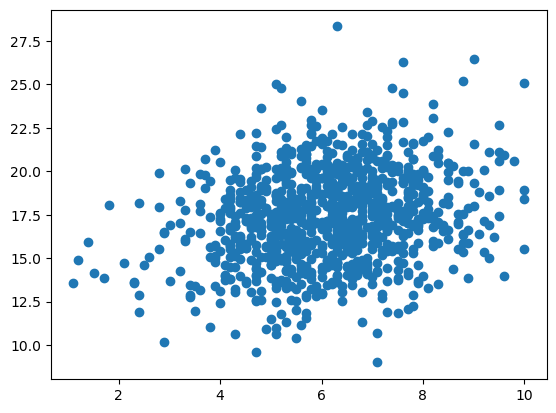

In [23]:
import numpy as np


plt.scatter(df['coding_skills'],df['salary_package_lpa'])

m,c=np.polyfit(df['coding_skills'],df['salary_package_lpa'],1)

<Axes: xlabel='coding_skills', ylabel='salary_package_lpa'>

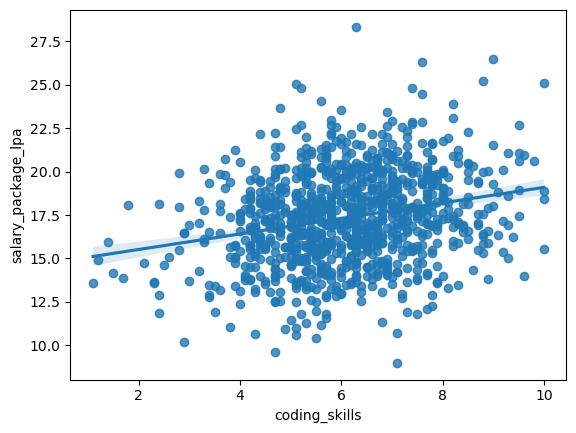

In [24]:
import seaborn as sns
sns.regplot(x='coding_skills',y='salary_package_lpa',data=df)

In [25]:
x=df['coding_skills']
y=df['salary_package_lpa']

In [30]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [32]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x_train.values.reshape(-1,1), y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [33]:
y_pred = model.predict(x_test.values.reshape(-1,1))
y_pred

array([16.64055023, 17.92382989, 17.49607   , 16.98275814, 16.51222227,
       17.1538621 , 17.75272594, 17.02553413, 17.79550192, 16.89720617,
       18.13770983, 16.93998215, 17.83827791, 17.23941407, 17.58162198,
       17.49607   , 17.02553413, 17.06831012, 16.89720617, 17.83827791,
       17.75272594, 17.62439797, 16.29834233, 16.42667029, 16.89720617,
       17.66717396, 18.05215786, 17.62439797, 17.23941407, 17.75272594,
       17.1538621 , 18.56546972, 17.70994995, 17.41051803, 17.23941407,
       17.19663808, 18.09493384, 17.1538621 , 17.62439797, 17.79550192,
       18.52269373, 17.32496605, 17.41051803, 16.72610221, 17.11108611,
       16.98275814, 17.83827791, 18.2660378 , 17.36774204, 17.41051803,
       17.66717396, 17.36774204, 15.74225447, 16.89720617, 17.62439797,
       17.62439797, 17.92382989, 17.45329402, 18.13770983, 18.05215786,
       17.41051803, 17.8810539 , 18.18048582, 18.05215786, 16.81165419,
       17.53884599, 16.93998215, 18.13770983, 17.75272594, 17.15

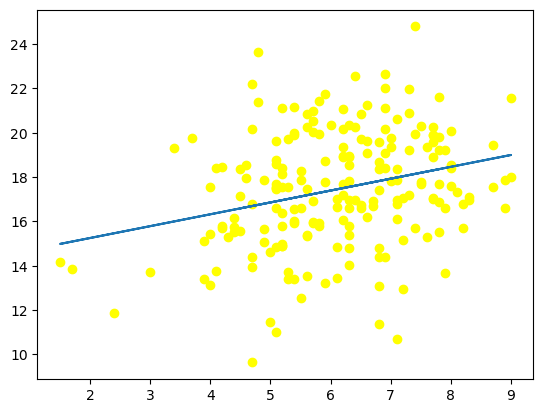

In [37]:
plt.scatter(x_test,y_test,color='yellow')

m,c=np.polyfit(x_test,y_test,1)
plt.plot(x_test,m*x_test+c)

In [39]:
import streamlit as st
import pandas as pd
from sklearn.linear_model import LinearRegression

st.title("Salary Package Prediction")

# Upload dataset
file = st.file_uploader("Upload Placement Dataset", type=["csv"])

if file is not None:

    df = pd.read_csv(file)

    st.subheader("Dataset Preview")
    st.write(df.head())

    # keep required columns
    df = df[['coding_skills','salary_package_lpa']]
    df = df.dropna()
    df = df.head(1000)

    X = df[['coding_skills']]
    y = df['salary_package_lpa']

    # Train model
    model = LinearRegression()
    model.fit(X, y)

    st.success("Model Trained Successfully")

    # User input
    coding_skill = st.number_input(
        "Enter Coding Skills Score",
        min_value=0.0,
        max_value=10.0,
        step=0.1
    )

    if st.button("Predict Salary Package"):
        prediction = model.predict([[coding_skill]])
        st.write("Predicted Salary Package (LPA):", round(prediction[0],2))

2026-03-05 12:15:44.935 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-05 12:15:44.937 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-05 12:15:44.939 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-05 12:15:44.941 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-05 12:15:44.945 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-05 12:15:44.946 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-05 12:15:44.948 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-05 12:15:44.949 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar